In [1]:
import time
from pathlib import Path

import duckdb
import pandas as pd

CSV_DIR = Path("../data/q2_2026_csv").resolve()
PARQUET = Path("../data/parquet/drive_days_q2_2026.parquet").resolve()
CSV_GLOB = str(CSV_DIR / "*.csv")

con = duckdb.connect()
print(len(list(CSV_DIR.glob("*.csv"))), "CSV files")

91 CSV files


In [2]:
start = time.time()
con.sql(f"""
    COPY (
        SELECT
            CAST(date AS DATE)              AS date,
            serial_number,
            trim(model)                     AS model,
            CAST(capacity_bytes AS BIGINT)  AS capacity_bytes,
            CAST(failure AS INTEGER)        AS failure,
            datacenter,
            CAST(cluster_id AS INTEGER)     AS cluster_id,
            CAST(vault_id AS INTEGER)       AS vault_id,
            CAST(pod_id AS INTEGER)         AS pod_id,
            CAST(pod_slot_num AS INTEGER)   AS pod_slot_num,
            filename                        AS source_file
        FROM read_csv('{CSV_GLOB}', all_varchar=true, union_by_name=true, filename=true)
    ) TO '{PARQUET}' (FORMAT parquet, COMPRESSION zstd)
""")
print(f"Conversion took {time.time() - start:.0f} seconds")

Conversion took 27 seconds


In [3]:

csv_bytes = sum(p.stat().st_size for p in CSV_DIR.glob("*.csv"))
pq_bytes = PARQUET.stat().st_size
print(f"CSV:     {csv_bytes / 1e9:.2f} GB")
print(f"Parquet: {pq_bytes / 1e9:.2f} GB  ({csv_bytes / pq_bytes:.0f}x smaller)\n")

def timed(sql):
    start = time.time()
    con.sql(sql).fetchall()
    return time.time() - start

t_csv = timed(f"SELECT model, count(*) FROM read_csv('{CSV_GLOB}', all_varchar=true) GROUP BY ALL")
t_pq = timed(f"SELECT model, count(*) FROM '{PARQUET}' GROUP BY ALL")
print(f"Same query on CSV:     {t_csv:.1f} s")
print(f"Same query on Parquet: {t_pq:.1f} s  ({t_csv / t_pq:.0f}x faster)")

CSV:     12.58 GB
Parquet: 0.31 GB  (40x smaller)

Same query on CSV:     16.6 s
Same query on Parquet: 0.0 s  (356x faster)


In [4]:
con.sql(f"CREATE OR REPLACE VIEW dd AS SELECT * FROM '{PARQUET}'")
con.sql("SELECT count(*) AS rows, min(date) AS first_day, max(date) AS last_day FROM dd").df()

,rows,first_day,last_day
0,31968003,2026-04-01,2026-06-30


In [5]:
per_day = con.sql("""
    SELECT
        date,
        count(*)                                   AS rows,
        count(DISTINCT serial_number)              AS drives,
        count(*) - count(DISTINCT serial_number)   AS duplicate_rows,
        sum(failure)                               AS failures,
        count(*) - count(datacenter)               AS blank_datacenter,
        count(*) - count(pod_slot_num)             AS no_slot
    FROM dd
    GROUP BY date
    ORDER BY date
""").df()

print("days:", len(per_day))
print("days with duplicates:", (per_day["duplicate_rows"] > 0).sum())
print("days with blank datacenter:", (per_day["blank_datacenter"] > 0).sum())
print("total failures in quarter:", per_day["failures"].sum())
per_day.describe()

days: 91
days with duplicates: 0
days with blank datacenter: 0
total failures in quarter: 1522.0


,date,rows,drives,duplicate_rows,failures,blank_datacenter,no_slot
count,91,91.000000,91.000000,91.0,91.000000,91.0,91.000000
mean,2026-05-16 00:00:00,351296.736264,351296.736264,0.0,16.725275,0.0,4336.483516
min,2026-04-01 00:00:00,345143.000000,345143.000000,0.0,3.000000,0.0,3985.000000
25%,2026-04-23 12:00:00,349286.500000,349286.500000,0.0,10.000000,0.0,4058.500000
50%,2026-05-16 00:00:00,351467.000000,351467.000000,0.0,14.000000,0.0,4110.000000
75%,2026-06-07 12:00:00,354173.000000,354173.000000,0.0,22.000000,0.0,4389.000000
max,2026-06-30 00:00:00,355284.000000,355284.000000,0.0,42.000000,0.0,6289.000000
std,NaN,3031.874678,3031.874678,0.0,8.432827,0.0,474.825122


         date    rows  change_pct
19 2026-04-20  348919    0.513052
27 2026-04-28  350470    0.322031
52 2026-05-23  351899    0.251555
11 2026-04-12  347458    0.230775
35 2026-05-06  351395    0.225325


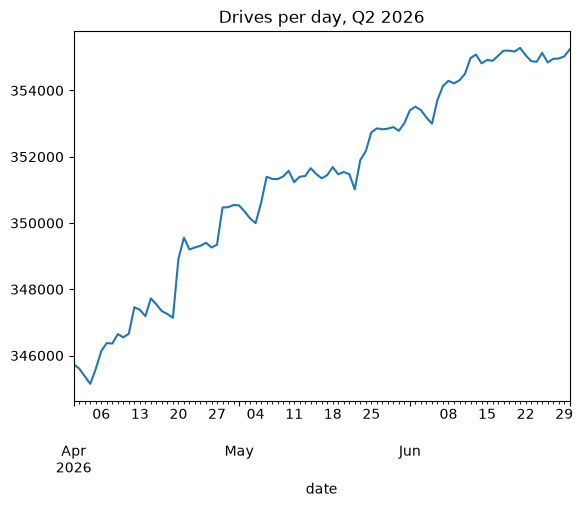

In [13]:
per_day["change_pct"] = per_day["rows"].pct_change() * 100
print(per_day.reindex(per_day["change_pct"].abs().sort_values(ascending=False).index)
      [["date", "rows", "change_pct"]].head(5))

ax = per_day.plot(x="date", y="rows", title="Drives per day, Q2 2026", legend=False)
ax.figure.savefig("../docs/evidence/q2_2026_drives_per_day.png", dpi=150, bbox_inches="tight")

In [7]:
con.sql("""
    WITH first_failure AS (
        SELECT serial_number, min(date) AS failed_on
        FROM dd
        WHERE failure = 1
        GROUP BY serial_number
    )
    SELECT
        (SELECT count(*) FROM first_failure) AS failed_drives,
        count(DISTINCT f.serial_number)      AS seen_again_after_failing
    FROM first_failure f
    JOIN dd d
      ON d.serial_number = f.serial_number
     AND d.date > f.failed_on
""").df()

,failed_drives,seen_again_after_failing
0,1522,0


In [8]:
con.sql("""
    SELECT
        count(*) FILTER (WHERE capacities > 1) AS drives_with_changing_capacity,
        count(*) FILTER (WHERE models > 1)     AS drives_with_changing_model
    FROM (
        SELECT serial_number,
               count(DISTINCT capacity_bytes) AS capacities,
               count(DISTINCT model)          AS models
        FROM dd
        GROUP BY serial_number
    )
""").df()

,drives_with_changing_capacity,drives_with_changing_model
0,0,0


In [9]:
con.sql("""
    SELECT
        'all drives' AS scope,
        sum(failure) AS failures,
        count(*)     AS drive_days,
        round(sum(failure) / (count(*) / 365.0) * 100, 2) AS afr_pct
    FROM dd
    UNION ALL
    SELECT
        'excluding boot drives (no slot)',
        sum(failure),
        count(*),
        round(sum(failure) / (count(*) / 365.0) * 100, 2)
    FROM dd
    WHERE pod_slot_num IS NOT NULL
""").df()

,scope,failures,drive_days,afr_pct
0,all drives,1522.0,31968003,1.74
1,excluding boot drives (no slot),479.0,31573383,0.55


In [10]:
print("1) Failure rows: how many have no slot?")
print(con.sql("""
    SELECT failure,
           count(*) AS rows,
           count(*) FILTER (WHERE pod_slot_num IS NULL) AS no_slot
    FROM dd
    GROUP BY failure
""").df(), "\n")

print("2) Failed drives with no slot: did they have a slot the day before?")
print(con.sql("""
    WITH failed_no_slot AS (
        SELECT serial_number, date
        FROM dd
        WHERE failure = 1 AND pod_slot_num IS NULL
    )
    SELECT count(*) AS failed_no_slot,
           count(*) FILTER (WHERE prev.pod_slot_num IS NOT NULL) AS had_slot_day_before
    FROM failed_no_slot f
    LEFT JOIN dd prev
      ON prev.serial_number = f.serial_number
     AND prev.date = f.date - 1
""").df(), "\n")

print("3) Better rule: a boot drive NEVER has a slot, on any day")
print(con.sql("""
    WITH boot_drives AS (
        SELECT serial_number
        FROM dd
        GROUP BY serial_number
        HAVING count(pod_slot_num) = 0
    )
    SELECT
        (SELECT count(*) FROM boot_drives) AS boot_drives,
        sum(failure) AS failures,
        count(*)     AS drive_days,
        round(sum(failure) / (count(*) / 365.0) * 100, 2) AS afr_pct
    FROM dd
    WHERE serial_number NOT IN (SELECT serial_number FROM boot_drives)
""").df())

1) Failure rows: how many have no slot?
   failure      rows  no_slot
0        0  31966481   393577
1        1      1522     1043 

2) Failed drives with no slot: did they have a slot the day before?
   failed_no_slot  had_slot_day_before
0            1043                  631 

3) Better rule: a boot drive NEVER has a slot, on any day
   boot_drives  failures  drive_days  afr_pct
0         4071    1433.0    31612054     1.65


In [11]:
con.sql("""
    WITH never_slot AS (
        SELECT serial_number,
               max(capacity_bytes) AS capacity,
               max(failure)        AS failed
        FROM dd
        GROUP BY serial_number
        HAVING count(pod_slot_num) = 0
    )
    SELECT
        CASE WHEN capacity < 1e12 THEN 'under 1 TB' ELSE '1 TB or more' END AS size_class,
        count(*)    AS drives,
        sum(failed) AS failed_drives
    FROM never_slot
    GROUP BY ALL
""").df()

,size_class,drives,failed_drives
0,1 TB or more,122,89.0
1,under 1 TB,3949,0.0


In [12]:
con.sql("""
    WITH boot_drives AS (
        SELECT serial_number
        FROM dd
        GROUP BY serial_number
        HAVING count(pod_slot_num) = 0
           AND max(capacity_bytes) < 1e12
    )
    SELECT
        (SELECT count(*) FROM boot_drives) AS boot_drives,
        sum(failure) AS failures,
        count(*)     AS drive_days,
        round(sum(failure) / (count(*) / 365.0) * 100, 2) AS afr_pct
    FROM dd
    WHERE serial_number NOT IN (SELECT serial_number FROM boot_drives)
""").df()

,boot_drives,failures,drive_days,afr_pct
0,3949,1522.0,31614298,1.76
